In [1]:
import xarray
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms.functional as F
from GeoSSL.geossl.datasets import EuroSATRGB, get_dataset_spec
import torchvision.transforms as T
from torch.utils.data import Dataset

In [2]:
def plot_tile_image(tile_raster):
    red = tile_raster["red"].squeeze()
    green = tile_raster["green"].squeeze()
    blue = tile_raster["blue"].squeeze()

    rgb = np.dstack((red, green, blue))

    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

    plt.figure(figsize=(3,3))
    plt.imshow(rgb)
    plt.axis('off')
    plt.show()

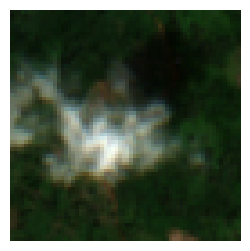

In [3]:
ar = xarray.load_dataset("data/ghana-grid-tiles/tile_5.ncf")
plot_tile_image(ar)

In [4]:
from scripts.gh_tile_dataset import GhanaTileDataset


dataset = GhanaTileDataset("data/ghana-grid-tiles")
print(len(dataset))
print(dataset[0].shape)


OSError: [Errno -51] NetCDF: Unknown file format: '/home/eli/Documents/ML/remote-sensing-ssl/data/ghana-grid-tiles/tile_178705.ncf'

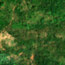

In [ ]:
F.to_pil_image(dataset[389])

In [ ]:
dataset_id = "eurosat_rgb"

dataset_spec = get_dataset_spec(dataset_id)
normalize = T.Normalize(mean=dataset_spec.mean, std=dataset_spec.std)

transform = T.Compose(
        [
            T.Resize(dataset_spec.size),
            T.CenterCrop(dataset_spec.crop_size),
            *([T.ToTensor()] if dataset_id == "eurosat_rgb" else []),
            normalize,
        ]
    )

dataset = EuroSATRGB(transform=transform, root="data/eurosat", split="val")

In [ ]:
dataset[0]

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

In [ ]:
import os
os.path.basename(dataset.eurosat.imgs[0][0])

'AnnualCrop_1008.tif'

In [5]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [6]:
## loading eurosat_rgb features
eurosat_rgb_simclr = pd.read_csv("data/features/eurosat_rgb-simclr-.csv")

In [7]:
features = eurosat_rgb_simclr.drop(columns=["image_name", "label"])

In [8]:
pca = PCA(n_components=2)
features_decomposed = pca.fit_transform(features)

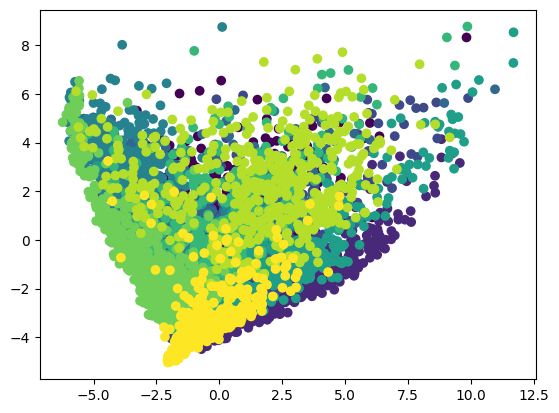

In [9]:
plt.scatter(features_decomposed[:, 0], features_decomposed[:, 1], c=eurosat_rgb_simclr["label"])

In [10]:
def pca_decompose(features, n_components=2):
    pca = PCA(n_components=n_components)
    features_decomposed = pca.fit_transform(features)
    print("Explained Variance: ", sum(pca.explained_variance_ratio_))
    return features_decomposed

In [11]:
# def plot_pca(df):
#     features = df[["feature"]]
#     features_decomposed = pca_decompose(features, n_components)
#     plt.scatter(features_decomposed[:, 0], features_decomposed[:, 1], c=eurosat_rgb_simclr["label"])
#     plt.colorbar()
#     plt.show()
#     return features_decomposed

In [ ]:
tsne = TSNE(n_components=2)

features_decomposed = tsne.fit_transform(features)

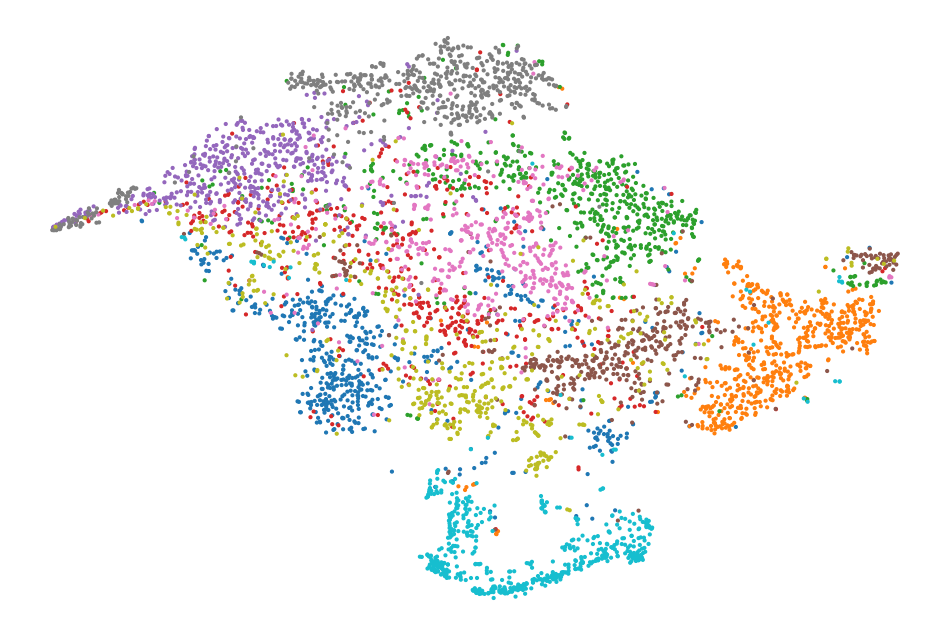

In [16]:
plt.figure(figsize=(12,8))
plt.scatter(features_decomposed[:, 0], features_decomposed[:, 1], c=eurosat_rgb_simclr["label"], s=4, cmap="tab10")
plt.axis(False)
plt.show()

In [2]:
import pandas as pd
from glob import glob

In [3]:
files = glob("data/features/ghana*.csv")

In [8]:
pd.read_csv(files[0]).isna().sum().sum()

np.int64(16896)

In [11]:
pd.read_csv(files[0]).dropna(axis=0).shape

(2789, 517)

In [13]:
df = pd.read_csv(files[0])

In [15]:
df[df.isna()]

,image_name,x_min,x_max,y_min,y_max,feature_0,feature_1,feature_2,feature_3,feature_4,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2819,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df[~df.isna().any(axis=1)]

,image_name,x_min,x_max,y_min,y_max,feature_0,feature_1,feature_2,feature_3,feature_4,...,feature_502,feature_503,feature_504,feature_505,feature_506,feature_507,feature_508,feature_509,feature_510,feature_511
0,tile_8.ncf,516575.0,517205.0,633955.0,634595.0,0.545886,0.993787,0.000000,0.001472,0.003183,...,0.272801,0.413335,0.394891,0.202181,0.512356,0.554110,0.290525,0.886958,0.160477,0.000000
1,tile_626.ncf,516435.0,517065.0,1026745.0,1027375.0,0.687259,1.010129,0.010796,0.000000,1.460681,...,0.000000,0.000000,0.000000,0.097200,0.614350,0.286756,0.017824,0.075485,0.157615,0.000000
2,tile_510.ncf,516465.0,517095.0,953005.0,953645.0,0.334519,0.883582,0.005809,0.000000,2.936931,...,0.025297,0.006864,0.000000,0.024842,1.044814,0.910726,0.064319,0.043248,0.166138,0.329920
3,tile_152309.ncf,621605.0,622235.0,637885.0,638525.0,0.055034,1.436059,0.000000,0.000000,0.173941,...,0.030416,1.145210,0.000000,0.005277,1.001750,0.797238,0.045991,0.034704,0.097263,0.063352
4,tile_917.ncf,516355.0,516975.0,1211715.0,1212355.0,0.803406,1.123963,0.000000,0.079985,0.300949,...,0.005664,0.002631,0.000000,0.000000,0.615382,0.024630,0.016312,0.008559,0.083476,0.023236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2817,tile_308603.ncf,728395.0,729035.0,833425.0,834065.0,0.476085,1.023129,0.000000,0.004658,1.662668,...,0.261412,0.130313,0.000000,0.009529,1.344121,0.946355,0.243413,0.262254,0.269410,0.153133
2818,tile_334127.ncf,747085.0,747725.0,629985.0,630625.0,0.458925,0.769504,0.000000,0.000000,0.245467,...,0.207196,0.064512,0.676319,0.091429,0.923423,1.233586,0.265207,0.028073,0.214825,0.053151
2819,tile_433.ncf,516485.0,517115.0,904065.0,904705.0,0.599851,0.802905,0.000000,0.000000,0.285289,...,0.009734,0.414608,0.016056,0.141293,0.843229,0.937254,0.157438,0.193450,0.181352,0.174719
2820,tile_757.ncf,516405.0,517035.0,1110005.0,1110645.0,0.640124,1.433815,0.000000,0.020504,0.756154,...,0.010833,0.006748,0.000000,0.016509,0.644543,0.000000,0.024067,0.031795,0.106733,0.033096
